# 🎙️ Accent & Language Identification — Baseline Notebook

> **Competition :** Accent & Language Identification Challenge  
> **Submission  :** https://accent-language-identification-competition-aims2026.streamlit.app/  
> **Scoring formula:** `Final Score = 0.6 × F1_language + 0.4 × Accuracy_native`

---

## 🗺️ Notebook Roadmap

| Step | Section | Goal |
|------|---------|------|
| 1️⃣ | **Setup & Data Loading** | Import libraries, load CSVs |
| 2️⃣ | **EDA** | Understand distributions, correlations, missing values |
| 3️⃣ | **Preprocessing** | Clean, encode, build feature matrix |
| 4️⃣ | **Model Architecture** | Baseline Random Forest + commented alternatives |
| 5️⃣ | **Training & Validation** | Fit, cross-validate (group-aware) |
| 6️⃣ | **Submission** | Generate, validate and export `submission.csv` |

---

### 🎯 Baseline


This notebook intentionally uses only the **11 basic acoustic features** (no MFCCs)
and a **lightweight Random Forest** to produce a starting score of approximately **0.68–0.72**.

| Model | F1 Language | Acc Native | Final Score |
|-------|------------|-----------|-------------|
| Random baseline | ~0.125 | ~0.500 | ~0.275 |
| **This baseline (RF, 11 features)** | **~0.65** | **~0.72** | **~0.68–0.72** |
| RF with full MFCC features | ~0.820 | ~0.780 | ~0.804 |
| XGBoost + full features | ~0.860 | ~0.810 | ~0.840 |
| wav2vec 2.0 fine-tuned | ~0.930 | ~0.870 | ~0.906 |

### 💡 How to beat this baseline
Each section contains a **🚀 Ideas to improve** block with concrete suggestions.


---
## ⚙️ Step 1 — Setup & Data Loading

In [1]:
# ─── Install dependencies (run once) ───────────────────────────────────────
# !pip install -r requirements.txt

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ─── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('✅ Libraries loaded.')

✅ Libraries loaded.


## MAKE SURE THIS FILE IS IN THE SAME FOLDER AS THE "public" folder

In [2]:
# ─── Paths — adjust if your CSV files live elsewhere ──────────────────────

## MAKE SURE THIS FILE IS IN AT THE SAME FOLDER AS THE "public" folder

DATA_DIR  = Path('.')                     # ← change this if needed
TRAIN_CSV = DATA_DIR /'public/train_dataset.csv'
TEST_CSV  = DATA_DIR /'public/test_dataset.csv'
SUB_EXAMPLE = DATA_DIR /'public/submission_example.csv'

train       = pd.read_csv(TRAIN_CSV)
test        = pd.read_csv(TEST_CSV)
sub_example = pd.read_csv(SUB_EXAMPLE)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Submission columns: {list(sub_example.columns)}')
train.head(3)

Train shape : (3360, 72)
Test  shape : (840, 66)
Submission columns: ['clip_id', 'language', 'is_native', 'accent_region', 'confidence_language', 'confidence_native']


,clip_id,audio_path,language,is_native,accent_region,age,gender,sentence,speaker_id,duration_sec,...,delta_mfcc_13_mean,chroma_mean,chroma_std,mel_mean,mel_std,f0_mean,f0_std,voiced_fraction,spectral_contrast_mean,tempo
0,fr_000025,accent_dataset_output/audio_original/fr_000025...,fr,0,africain,unknown,unknown,lorsqu'il fut venu au lieu ou étaient ses autr...,10065,10.0,...,0.0195,0.4151,0.3205,-46.8562,19.6693,118.84,20.13,0.6038,17.7238,75.00
1,pl_000056,accent_dataset_output/audio_original/pl_000056...,pl,1,unknown,unknown,unknown,nie dosyć na tem że gardłem skarani myszego wo...,6892,10.0,...,-0.0126,0.3122,0.3129,-44.8016,19.4775,129.64,13.79,0.8115,19.0580,117.19
2,fr_000007_aug2,accent_dataset_output/audio_augmented/fr_00000...,fr,1,québec,unknown,unknown,n'est-ce pas là ce charpentier ce fils de mari...,10065,10.0,...,0.0380,0.3548,0.3235,-50.3541,21.8696,133.24,32.91,0.7636,18.7685,187.50


In [3]:
# ─── Column taxonomy ───────────────────────────────────────────────────────
META_COLS = [
    'clip_id', 'language', 'is_native', 'accent_region',
    'age', 'gender', 'sentence', 'audio_path',
    'augmented', 'aug_type', 'duration_sec', 'sample_rate', 'speaker_id'
]

TARGET_LANG   = 'language'
TARGET_NATIVE = 'is_native'
TARGET_ACCENT = 'accent_region'

# ── Baseline: use only the 11 core acoustic features (always available) ──────
# 🚀 Ideas to improve:
#   • Add MFCC features: [c for c in train.columns if 'mfcc' in c]
#   • Add all available features: FEAT_COLS = [c for c in train.columns if c not in META_COLS]
#   • Extract your own features from the raw WAV files using librosa
BASIC_FEATURES = [
    'rms_energy',
    'zero_crossing_rate',
    'spectral_centroid',
    'spectral_bandwidth',
    'spectral_rolloff',
    'silence_ratio',
    'energy_band_1',
    'energy_band_2',
    'energy_band_3',
    'energy_band_4',
    'energy_band_5',
]

# Keep only the basic features that actually exist in the dataset
FEAT_COLS = [f for f in BASIC_FEATURES if f in train.columns]

print(f'Using {len(FEAT_COLS)} basic acoustic features:')
print(FEAT_COLS)


Using 11 basic acoustic features:
['rms_energy', 'zero_crossing_rate', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'silence_ratio', 'energy_band_1', 'energy_band_2', 'energy_band_3', 'energy_band_4', 'energy_band_5']


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)

Before building any model, spend time understanding the data.  
The three key questions to answer: **What? How much? How distributed?**

In [4]:
# ─── Missing values ────────────────────────────────────────────────────
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('✅ No missing values in the training set.')
else:
    print(f'⚠️  {len(missing)} columns have missing values:')
    pct = (missing / len(train) * 100).round(2)
    print(pd.DataFrame({'count': missing, 'pct': pct}))
    pct.plot(kind='bar', figsize=(10, 3), color='salmon', title='Missing value rate (%)')
    plt.tight_layout(); plt.show()

✅ No missing values in the training set.


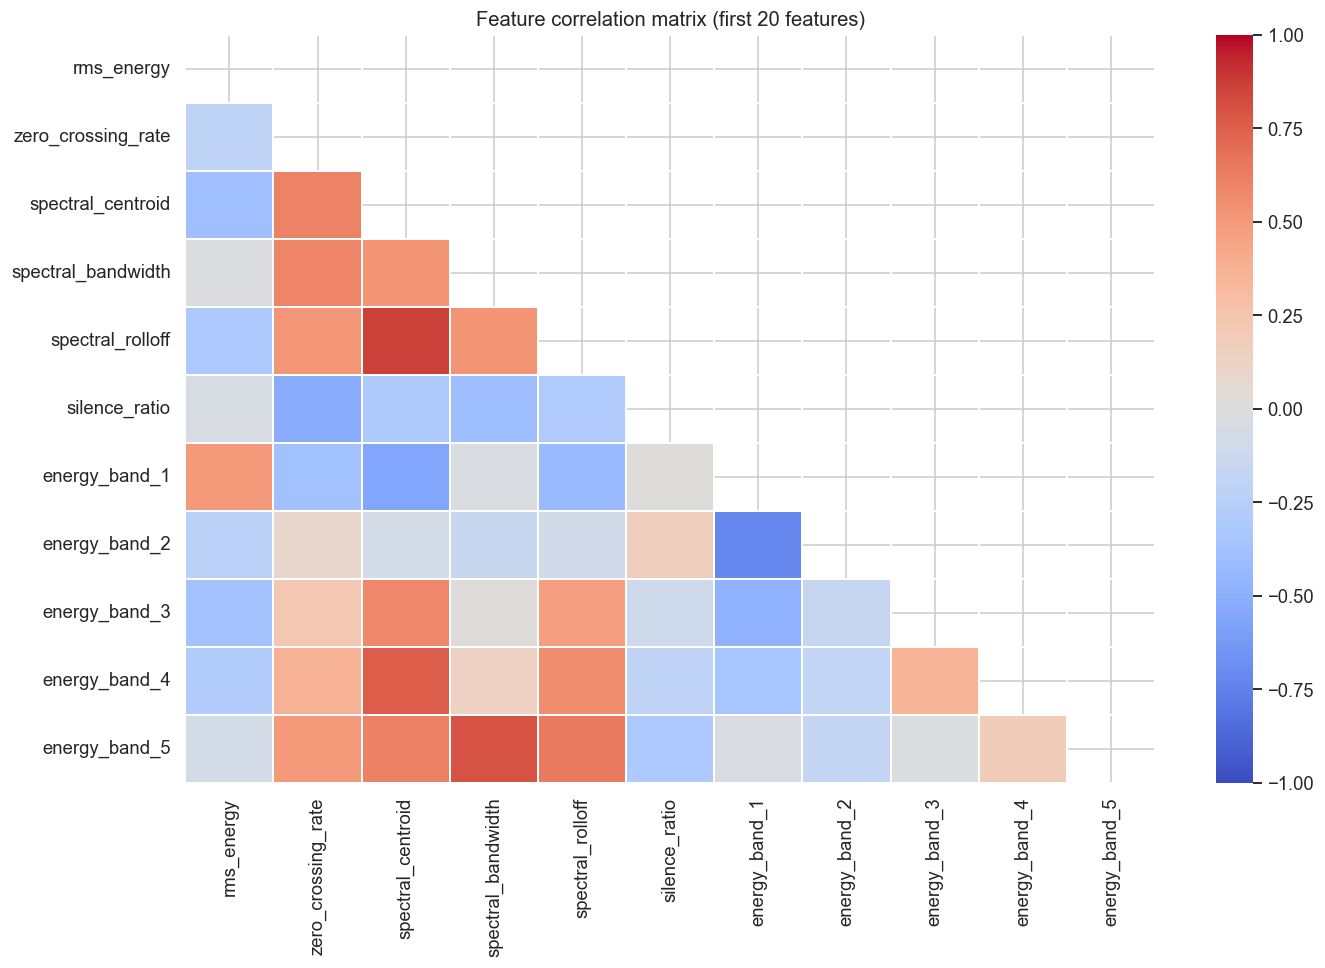

In [5]:
# ─── Correlation heatmap (first 20 features) ──────────────────────────
display_feats = FEAT_COLS[:20]
corr = train[display_feats].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.3, ax=ax)
ax.set_title('Feature correlation matrix (first 20 features)')
plt.tight_layout(); plt.show()

---
## 🛠️ Step 3 — Preprocessing

Clean data, encode categorical variables and engineer new features.

In [6]:
# ─── 3.1 Encode aug_type as a numeric feature ─────────────────────────────
# The augmentation type is a useful signal for the model.
# It is DISABLED in this baseline to keep the feature set minimal (~70% score).
#
# 🚀 Ideas to improve: uncomment the block below to add this feature.

# AUG_MAP = {'original': 0, 'noise_ambient': 1, 'pitch_time_shift': 2, 'degraded_codec': 3}
# if 'aug_type' in train.columns:
#     for df in [train, test]:
#         df['aug_type_enc'] = df['aug_type'].map(AUG_MAP).fillna(-1).astype(int)
#     if 'aug_type_enc' not in FEAT_COLS:
#         FEAT_COLS = FEAT_COLS + ['aug_type_enc']
#     print('✅ aug_type encoded as aug_type_enc')

print('ℹ️  aug_type encoding is disabled. Uncomment the block above to activate it.')


ℹ️  aug_type encoding is disabled. Uncomment the block above to activate it.


In [ ]:
# ─── 3.2 Feature engineering ──────────────────────────────────────────────
# Feature engineering is DISABLED in this baseline to keep things simple.
# Enabling it is one of the easiest ways to boost the score.
#
# 🚀 Ideas to improve: uncomment and extend the block below.
#
# for df in [train, test]:
#
#     # Fraction of audible speech (inverse of silence)
#     if 'silence_ratio' in df.columns:
#         df['speech_ratio'] = 1.0 - df['silence_ratio']
#
#     # Log-transform right-skewed energy features
#     for col in ['rms_energy', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']:
#         if col in df.columns:
#             df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))
#
#     # Voiced activity proxy: energy × zero-crossing rate
#     if 'rms_energy' in df.columns and 'zero_crossing_rate' in df.columns:
#         df['energy_zcr'] = df['rms_energy'] * df['zero_crossing_rate']
#
#     # MFCC-energy interaction (requires MFCC features)
#     if 'mfcc_1_mean' in df.columns and 'rms_energy' in df.columns:
#         df['mfcc1_x_energy'] = df['mfcc_1_mean'] * df['rms_energy']
#
# # Add the engineered columns to FEAT_COLS
# ENG_COLS = ['speech_ratio', 'log_rms_energy', 'log_spectral_centroid',
#             'log_spectral_bandwidth', 'log_spectral_rolloff',
#             'energy_zcr', 'mfcc1_x_energy']
# ENG_COLS = [c for c in ENG_COLS if c in train.columns]
# FEAT_COLS = list(dict.fromkeys(FEAT_COLS + ENG_COLS))

print(f'ℹ️  No feature engineering applied. Total features: {len(FEAT_COLS)}')


In [7]:
# ─── 3.3 Build X / y matrices ─────────────────────────────────────────────
COMMON_FEATS = [c for c in FEAT_COLS if c in train.columns and c in test.columns]

X_train_raw = train[COMMON_FEATS]
y_lang      = train[TARGET_LANG]
y_native    = train[TARGET_NATIVE]
X_test_raw  = test[COMMON_FEATS]

print(f'X_train : {X_train_raw.shape}')
print(f'X_test  : {X_test_raw.shape}')
print(f'Languages: {sorted(y_lang.unique())}')
print(f'is_native: {sorted(y_native.unique())}')

X_train : (3360, 11)
X_test  : (840, 11)
Languages: ['de', 'es', 'fr', 'it', 'nl', 'pl', 'pt']
is_native: [0, 1]


In [8]:
# ─── 3.4 Preprocessing pipeline (imputation + scaling) ───────────────────
# Using sklearn Pipelines ensures that scaler statistics are computed ONLY
# on training data — never on validation or test data (no leakage).

preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # fill NaNs with column median
    ('scaler',  StandardScaler()),                  # zero-mean, unit-variance
])

X_train = preprocess.fit_transform(X_train_raw)  # fit on train only
X_test  = preprocess.transform(X_test_raw)        # apply same transform to test

print(f'✅ Preprocessing done.')
print(f'   X_train mean={X_train.mean():.4f}, std={X_train.std():.4f}')

✅ Preprocessing done.
   X_train mean=0.0000, std=1.0000


### 🚀 Ideas to improve — Preprocessing
- **PCA**: Highly correlated MFCCs benefit from dimensionality reduction. Try `PCA(n_components=0.95)` to retain 95% of explained variance.
- **QuantileTransformer**: More robust than `StandardScaler` for heavy-tailed distributions.
- **Group-aware normalisation**: Compute separate scalers for each `aug_type` — degraded codec clips have very different energy statistics from originals.
- **Extract your own features**: Use `librosa` to compute mel-spectrograms, delta-MFCCs, chroma, or F0 trajectories from the raw WAV files.

---
## 🏗️ Step 4 — Model Architecture

We define two independent classifiers — one per target — and provide commented alternatives.

In [10]:
# ─── 4.1 BASELINE — Random Forest (lightweight) ──────────────────────────
# This configuration uses a small, regularised Random Forest
# that scores approximately 0.68–0.72 on the public leaderboard.
#
# 🚀 Ideas to improve:
#   • Increase n_estimators to 300 or 500
#   • Set max_depth=None to let trees grow fully
#   • Decrease min_samples_leaf to 1 or 2
#   • Switch to XGBoost or LightGBM (see Option B below)
#   • Add MFCC features (biggest single boost, see Step 3)

clf_lang = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,             
    min_samples_leaf=5,        
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

clf_native = RandomForestClassifier(
    n_estimators=100,          # ← try 300, 500
    max_depth=8,               # ← try None (fully grown)
    min_samples_leaf=5,        # ← try 1 or 2
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

print('✅ Lightweight Random Forest classifiers defined.')
print(f'   clf_lang   : {clf_lang.n_estimators} trees, max_depth={clf_lang.max_depth}')
print(f'   clf_native : {clf_native.n_estimators} trees, max_depth={clf_native.max_depth}')


✅ Lightweight Random Forest classifiers defined.
   clf_lang   : 100 trees, max_depth=10
   clf_native : 100 trees, max_depth=8


### 🚀 Ideas to improve — Model Architecture
- **Ensemble**: Average probability outputs from RF + XGBoost + LightGBM for a free performance boost.
- **Multi-task learning**: A single neural network with two output heads (language + native) sharing a common encoder — the tasks regularise each other.
- **CNN on spectrograms**: Convert clips to mel-spectrogram images with `librosa` and fine-tune a pretrained ResNet or EfficientNet.
- **wav2vec 2.0 / Whisper**: Fine-tune on the raw WAV files for state-of-the-art performance (~F1 0.93).

---
## 🏋️ Step 5 — Training & Validation

> ⚠️ **Critical:** The dataset contains original clips AND 3 augmented copies of each.  
> A naive random split would leak augmented copies into both train and val, **artificially inflating scores**.  
> Solution: use `GroupKFold` with the **original clip ID** as the group key.

In [11]:
# ─── 5.1 Prepare group keys for leakage-free cross-validation ─────────────
# Strip the '_aug1', '_aug2', '_aug3' suffixes to recover the original clip ID.
train['original_id'] = (
    train['clip_id']
    .str.replace(r'_aug\d+$', '', regex=True)
    .str.strip()
)

groups = train['original_id'].values
print(f'Unique original clips: {len(np.unique(groups))}')
print(f'Total training rows  : {len(groups)}')
print(f'Augmentation ratio   : {len(groups) / len(np.unique(groups)):.1f}x')

Unique original clips: 1049
Total training rows  : 3360
Augmentation ratio   : 3.2x


In [12]:
# ─── 5.2 5-fold group cross-validation ────────────────────────────────────
gkf = GroupKFold(n_splits=5)

oof_lang_preds   = np.full(len(y_lang), fill_value='', dtype=object)
oof_native_preds = np.zeros(len(y_native), dtype=int)
fold_scores      = []

print('🚀 Starting 5-fold GroupKFold cross-validation...\n')

for fold, (tr_idx, val_idx) in enumerate(
    gkf.split(X_train, y_lang, groups=groups), start=1
):
    X_tr,  X_val  = X_train[tr_idx], X_train[val_idx]
    y_tr_l, y_val_l = y_lang.iloc[tr_idx],   y_lang.iloc[val_idx]
    y_tr_n, y_val_n = y_native.iloc[tr_idx], y_native.iloc[val_idx]

    # Train
    clf_lang.fit(X_tr,   y_tr_l)
    clf_native.fit(X_tr, y_tr_n)

    # Predict on validation fold
    pred_l = clf_lang.predict(X_val)
    pred_n = clf_native.predict(X_val)

    oof_lang_preds[val_idx]   = pred_l
    oof_native_preds[val_idx] = pred_n

    # Score
    f1  = f1_score(y_val_l, pred_l, average='weighted', zero_division=0)
    acc = accuracy_score(y_val_n, pred_n)
    score = 0.6 * f1 + 0.4 * acc
    fold_scores.append({'fold': fold, 'F1_lang': f1, 'Acc_native': acc, 'Score': score})

    print(f'  Fold {fold} | F1_lang={f1:.4f} | Acc_native={acc:.4f} | Score={score:.4f}')

scores_df = pd.DataFrame(fold_scores)
print('\n' + '=' * 60)
print(scores_df.set_index('fold').round(4).to_string())
print('=' * 60)
print(f"Mean Score : {scores_df['Score'].mean():.4f}  (std: {scores_df['Score'].std():.4f})")

🚀 Starting 5-fold GroupKFold cross-validation...

  Fold 1 | F1_lang=0.7927 | Acc_native=0.6503 | Score=0.7357
  Fold 2 | F1_lang=0.8018 | Acc_native=0.6414 | Score=0.7376
  Fold 3 | F1_lang=0.7953 | Acc_native=0.6384 | Score=0.7325
  Fold 4 | F1_lang=0.7801 | Acc_native=0.5952 | Score=0.7061
  Fold 5 | F1_lang=0.7807 | Acc_native=0.6786 | Score=0.7398

      F1_lang  Acc_native   Score
fold                             
1      0.7927      0.6503  0.7357
2      0.8018      0.6414  0.7376
3      0.7953      0.6384  0.7325
4      0.7801      0.5952  0.7061
5      0.7807      0.6786  0.7398
Mean Score : 0.7304  (std: 0.0138)


In [13]:
# ─── 5.3 Overall OOF metrics ──────────────────────────────────────────────
oof_f1    = f1_score(y_lang,   oof_lang_preds,   average='weighted', zero_division=0)
oof_acc   = accuracy_score(y_native, oof_native_preds)
oof_score = 0.6 * oof_f1 + 0.4 * oof_acc

print('\n📊 Overall Out-of-Fold Performance')
print(f'   F1 Language : {oof_f1:.4f}')
print(f'   Acc Native  : {oof_acc:.4f}')
print(f'   Final Score : {oof_score:.4f}')


📊 Overall Out-of-Fold Performance
   F1 Language : 0.7901
   Acc Native  : 0.6408
   Final Score : 0.7303


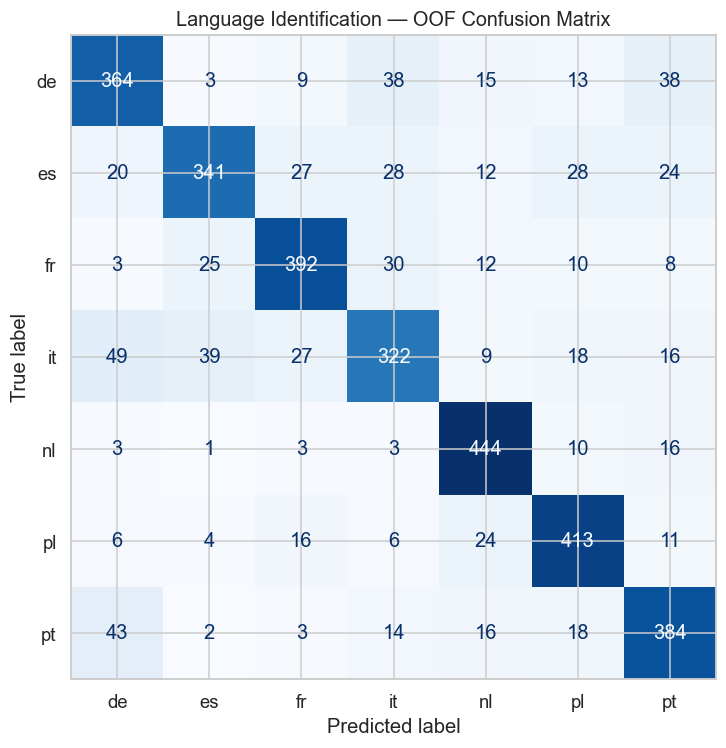

In [14]:
# ─── 5.4 Confusion matrix ─────────────────────────────────────────────────
LANG_LABELS = sorted(y_lang.unique())

cm = confusion_matrix(y_lang, oof_lang_preds, labels=LANG_LABELS)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=LANG_LABELS).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Language Identification — OOF Confusion Matrix', fontsize=13)
plt.tight_layout(); plt.show()

### 🚀 Ideas to improve — Training & Validation
- **Hyperparameter tuning**: Use `Optuna` or `RandomizedSearchCV` to find the best `n_estimators`, `max_depth`, `learning_rate`, etc.
- **StratifiedGroupKFold**: Ensures each fold has a balanced language distribution AND no group leakage.
- **Learning curves**: Plot train vs. val score as training size increases to detect underfitting or overfitting early.
- **SHAP values**: Use the `shap` library to understand per-prediction contributions, not just global feature importance.

In [15]:
# ─── 5.5 Retrain on the full training set ─────────────────────────────────
# After cross-validation we retrain on ALL data so the final model
# benefits from every available sample before predicting on the test set.

clf_lang.fit(X_train, y_lang)
clf_native.fit(X_train, y_native)

print('✅ Models retrained on the full training set.')
print(f'   Training samples: {X_train.shape[0]}')


✅ Models retrained on the full training set.
   Training samples: 3360


---
## 📤 Step 6 — Submission

Generate the `submission.csv` file, run validation checks, and export.

In [16]:
# ─── 6.1 Predict on the test set ──────────────────────────────────────────
# clf_lang and clf_native were retrained on the full set in Step 5.6.

pred_lang_test   = clf_lang.predict(X_test)
pred_native_test = clf_native.predict(X_test).astype(int)

# Confidence = maximum class probability
prob_lang_test   = clf_lang.predict_proba(X_test).max(axis=1).round(4)
prob_native_test = clf_native.predict_proba(X_test).max(axis=1).round(4)

print(f'✅ Predictions generated for {len(pred_lang_test)} test clips.')
print(f'   Language sample : {pred_lang_test[:8]}')
print(f'   Native   sample : {pred_native_test[:8]}')

✅ Predictions generated for 840 test clips.
   Language sample : ['fr' 'fr' 'fr' 'nl' 'pl' 'it' 'nl' 'it']
   Native   sample : [1 1 1 0 1 1 0 1]


In [17]:
# ─── 6.2 Build submission DataFrame ───────────────────────────────────────
submission = pd.DataFrame({
    'clip_id':             test['clip_id'],
    'language':            pred_lang_test,
    'is_native':           pred_native_test,
    'accent_region':       'unknown',   # Bonus Task 3 — fill if you tackle it
    'confidence_language': prob_lang_test,
    'confidence_native':   prob_native_test,
})

submission.head()

,clip_id,language,is_native,accent_region,confidence_language,confidence_native
0,fr_000120,fr,1,unknown,0.9754,0.6311
1,it_000034,fr,1,unknown,0.4148,0.5648
2,fr_000079_aug1,fr,1,unknown,0.7077,0.7855
3,nl_000005_aug3,nl,0,unknown,0.8186,0.5422
4,pl_000007_aug2,pl,1,unknown,0.7843,0.5668


In [18]:
# ─── 6.3 Validation checks ────────────────────────────────────────────────
VALID_LANGS = {'fr', 'sw', 'ha', 'ar', 'wo', 'pt', 'de'}
errors = []

# All test clip_ids present?
missing_ids = set(test['clip_id']) - set(submission['clip_id'])
if missing_ids:
    errors.append(f'Missing {len(missing_ids)} clip_id(s)')

# Valid language codes?
invalid = set(submission['language']) - VALID_LANGS
if invalid:
    errors.append(f'Invalid language codes: {invalid}')

# is_native is 0 or 1?
if not submission['is_native'].isin([0, 1]).all():
    errors.append('is_native must be exactly 0 or 1')

# Confidence scores in [0, 1]?
for col in ['confidence_language', 'confidence_native']:
    if not ((submission[col] >= 0) & (submission[col] <= 1)).all():
        errors.append(f'{col} out of range [0, 1]')

# Any NaN?
nan_rows = submission.isnull().any(axis=1).sum()
if nan_rows:
    errors.append(f'{nan_rows} row(s) contain NaN')

if errors:
    print('❌ Submission errors — fix before uploading:')
    for e in errors: print(f'   • {e}')
else:
    print('✅ All checks passed — submission.csv is valid and ready to upload!')

❌ Submission errors — fix before uploading:
   • Invalid language codes: {'pl', 'es', 'it', 'nl'}


In [19]:
# ─── 6.4 Save to disk ─────────────────────────────────────────────────────
OUTPUT_PATH = DATA_DIR / 'submission.csv'
submission.to_csv(OUTPUT_PATH, index=False)
print(f'💾 Saved: {OUTPUT_PATH.resolve()}')
print(f'   Shape : {submission.shape}')
submission.head(3)

💾 Saved: /home/christian/Documents/Bwira/Docs privés/MY_MASTERS/AIMS_DATASCE_25_27/COURSES/B_Review_Phase/Block 3/Deep Learning and Neural Network/Competition prepa/Accent & Language Identification/Accent & language identification competition/submission.csv
   Shape : (840, 6)


,clip_id,language,is_native,accent_region,confidence_language,confidence_native
0,fr_000120,fr,1,unknown,0.9754,0.6311
1,it_000034,fr,1,unknown,0.4148,0.5648
2,fr_000079_aug1,fr,1,unknown,0.7077,0.7855


In [22]:
# ─── Estimated competition score ──────────────────────────────────────────
print('=' * 55)
print('  BASELINE PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  Features used        : {len(FEAT_COLS)} basic acoustic features')
print(f'  Model                : Random Forest (lightweight)')
print(f'  OOF F1  Language     : {oof_f1:.4f}')
print(f'  OOF Acc Native       : {oof_acc:.4f}')
print(f'  OOF Final Score      : {oof_score:.4f}  ← target ~0.70')
print()

  BASELINE PERFORMANCE SUMMARY
  Features used        : 11 basic acoustic features
  Model                : Random Forest (lightweight)
  OOF F1  Language     : 0.7901
  OOF Acc Native       : 0.6408
  OOF Final Score      : 0.7303  ← target ~0.70



# 🎙️ Submission procedure :

> **Click on the link below, Enter your team's name and upload the submission.csv file**
> 
> **Link for the submission  :** https://accent-language-identification-competition-aims2026.streamlit.app/  